In [1]:
import os
import pandas as pd
import torch 
import torch.nn as nn 
import torch.optim as optim 
from torch.utils.data import Dataset, DataLoader, TensorDataset
from torchmetrics.regression import MeanSquaredError
device = torch.device("cpu") 

#Load Data
#Exclude Columns Related to Data on the Specific Director.
#Want this to be a tool for new directors/producers trying to break in
# So I don't want the model tied to director details
# Also drop the unused genres list column
cols_to_exclude = ["genres","director_name","director_professions","director_birthYear","director_deathYear", "Production budget $"]

target_cols = ["movie_title","Production budget $"]


x = pd.read_csv("movie_statistic_dataset_processed.csv",usecols=lambda column: column not in cols_to_exclude)
y = pd.read_csv("movie_statistic_dataset_processed.csv",usecols=target_cols)
# Convert Year String to Int
x['production_date'] = pd.to_datetime(x['production_date']).dt.year.astype(int)

#Set the title as the index
x = x.set_index('movie_title')
y = y.set_index('movie_title')

from sklearn.model_selection import train_test_split
#Split the data
rand_seed=1
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=rand_seed) 

# Scale Data (so consistent with other models)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler() 
X_train_scaled = scaler.fit_transform(X_train) 
X_test_scaled = scaler.transform(X_test)


#Batch Size
batch_size = 64

#Prepare Training Data
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32)
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size,shuffle=True)

print(f'X Tensor Size: {X_train_tensor.size()}')

#Prepare Testing Data
# Testing Data
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32 )
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

X Tensor Size: torch.Size([3504, 30])


Design The Neural Nets

In [2]:
input_size = 30 # Number of Input Features
step_1 = 64
step_2 = 32
step_3 = 16
step_4 = 8
step_5 = 4
step_6 = 2
output_size = 1 # 1 Feature at Output

class Hidden1(nn.Module):
    def __init__(self):
        super(Hidden1, self).__init__()
        #self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(input_size, step_1),
            nn.ReLU(),
            nn.Linear(step_1, step_2),
            nn.ReLU(),
            nn.Linear(step_2, output_size)
            
        )
    def forward(self, x):
        #x= self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits


class Hidden2(nn.Module):
    def __init__(self):
        super(Hidden2, self).__init__()
        #self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(input_size, step_1),
            nn.ReLU(),
            nn.Linear(step_1, step_2),
            nn.ReLU(),
            nn.Linear(step_2, step_3),
            nn.ReLU(),
            nn.Linear(step_3, output_size)
            
        )
    def forward(self, x):
        #x= self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits

class Hidden3(nn.Module):
    def __init__(self):
        super(Hidden3, self).__init__()
        #self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(input_size, step_1),
            nn.ReLU(),
            nn.Linear(step_1, step_2),
            nn.ReLU(),
            nn.Linear(step_2, step_3),
            nn.ReLU(),
            nn.Linear(step_3, step_4),
            nn.ReLU(),
            nn.Linear(step_4, output_size)
            
            
        )
    def forward(self, x):
        #x= self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits

class Hidden4(nn.Module):
    def __init__(self):
        super(Hidden4, self).__init__()
        #self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(input_size, step_1),
            nn.ReLU(),
            nn.Linear(step_1, step_2),
            nn.ReLU(),
            nn.Linear(step_2, step_3),
            nn.ReLU(),
            nn.Linear(step_3, step_4),
            nn.ReLU(),
            nn.Linear(step_4, step_5),
            nn.ReLU(),
            nn.Linear(step_5, output_size)
            
            
        )
    def forward(self, x):
        #x= self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits

class Hidden5(nn.Module):
    def __init__(self):
        super(Hidden5, self).__init__()
        #self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(input_size, step_1),
            nn.ReLU(),
            nn.Linear(step_1, step_2),
            nn.ReLU(),
            nn.Linear(step_2, step_3),
            nn.ReLU(),
            nn.Linear(step_3, step_4),
            nn.ReLU(),
            nn.Linear(step_4, step_5),
            nn.ReLU(),
            nn.Linear(step_5, step_6),
            nn.ReLU(),
            nn.Linear(step_6, output_size)
            
            
        )
    def forward(self, x):
        #x= self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits

In [3]:

from torchmetrics import MeanSquaredError
import matplotlib.pyplot as plt

# Training Loop
def trainloop(num_epochs, model, train_loader,optimizer, criterion):
    for epoch in range(num_epochs): 
        model.train() 
        for X,y in train_loader:
            optimizer.zero_grad() 
            y_pred = model(X) 
            loss = criterion(y_pred,y) 
            loss.backward() 
            optimizer.step() 
    

# Testing Loop
def testloop(model, test_loader,criterion):
    model.eval() # Not in training mode
    mse_metric = MeanSquaredError()
    with torch.no_grad():
        for X,y in test_loader:
            y_pred = model(X)
            mse_metric.update(y_pred,y)
    return mse_metric.compute()       
    
# Run Model            
def runNet(num_epochs, model ,trainload, testload, optimizer,criterion,variation): 
    testing_mse=[]
    
    for t in range(num_epochs):
        print(f"Epoch {t+1}\n----------")
        trainloop(num_epochs, model, trainload, optimizer, criterion)
        testing_mse.append(testloop(model, testload,criterion))
        
        
    print("Done")
    print(f'Test MSE in Final Epoch: {testing_mse[-1]}')
    #Plotting

    plt.scatter(range(1,num_epochs+1),testing_mse)
    plt.title(f'{variation} Testing MSE by Epoch')
    plt.show()    

        

Hidden 1: Hidden1(
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=30, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=1, bias=True)
  )
)
Hidden 2: Hidden2(
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=30, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=16, bias=True)
    (5): ReLU()
    (6): Linear(in_features=16, out_features=1, bias=True)
  )
)
Hidden 3: Hidden3(
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=30, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=16, bias=True)
    (5): ReLU()
    (6): Linear(in_features=16, out_features=8, bias=True)
    (7): ReLU()
    (8): Linear(in_featur

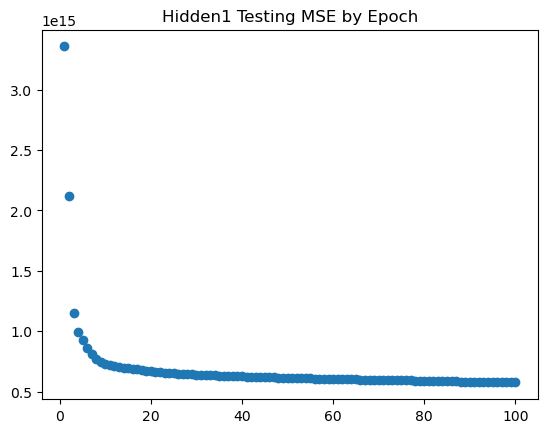

Epoch 1
----------
Epoch 2
----------
Epoch 3
----------
Epoch 4
----------
Epoch 5
----------
Epoch 6
----------
Epoch 7
----------
Epoch 8
----------
Epoch 9
----------
Epoch 10
----------
Epoch 11
----------
Epoch 12
----------
Epoch 13
----------
Epoch 14
----------
Epoch 15
----------
Epoch 16
----------
Epoch 17
----------
Epoch 18
----------
Epoch 19
----------
Epoch 20
----------
Epoch 21
----------
Epoch 22
----------
Epoch 23
----------
Epoch 24
----------
Epoch 25
----------
Epoch 26
----------
Epoch 27
----------
Epoch 28
----------
Epoch 29
----------
Epoch 30
----------
Epoch 31
----------
Epoch 32
----------
Epoch 33
----------
Epoch 34
----------
Epoch 35
----------
Epoch 36
----------
Epoch 37
----------
Epoch 38
----------
Epoch 39
----------
Epoch 40
----------
Epoch 41
----------
Epoch 42
----------
Epoch 43
----------
Epoch 44
----------
Epoch 45
----------
Epoch 46
----------
Epoch 47
----------
Epoch 48
----------
Epoch 49
----------
Epoch 50
----------
Epoch 51


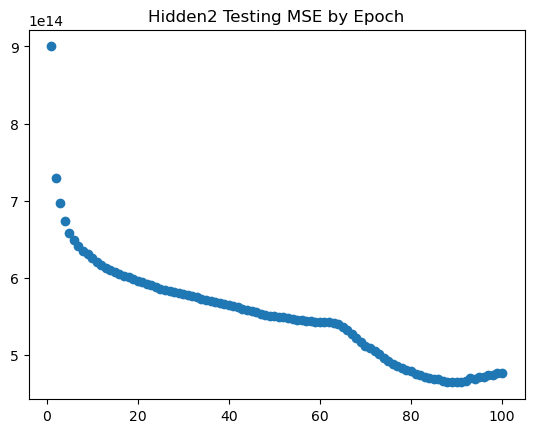

Epoch 1
----------
Epoch 2
----------
Epoch 3
----------
Epoch 4
----------
Epoch 5
----------
Epoch 6
----------
Epoch 7
----------
Epoch 8
----------
Epoch 9
----------
Epoch 10
----------
Epoch 11
----------


In [ ]:
# Build and Run Model
# fix random seed 
import random
import numpy as np
SEED = 1 
random.seed(SEED) 
np.random.seed(SEED) 
torch.manual_seed(SEED) 
if torch.cuda.is_available(): 
    torch.cuda.manual_seed_all(SEED)


# Test all 5 models with the same baseline lr, batch size and epochs
hidden1 = Hidden1()
hidden2 = Hidden2()
hidden3 = Hidden3()
hidden4 = Hidden4()
hidden5 = Hidden5()

num_epochs, lr = 100, 0.001

criterion = nn.MSELoss() # MSE Loss for Regression

# PRINT THE NETS
print(f'Hidden 1: {hidden1}')
print(f'Hidden 2: {hidden2}')
print(f'Hidden 3: {hidden3}')
print(f'Hidden 4: {hidden4}')
print(f'Hidden 5: {hidden5}')

# Run all the Nets
runNet(num_epochs=num_epochs, model=hidden1 ,trainload=train_loader, testload=test_loader, optimizer=torch.optim.Adam(hidden1.parameters(),lr=lr),criterion=criterion,variation="Hidden1")
runNet(num_epochs=num_epochs, model=hidden2 ,trainload=train_loader, testload=test_loader, optimizer=torch.optim.Adam(hidden2.parameters(),lr=lr),criterion=criterion,variation="Hidden2")
runNet(num_epochs=num_epochs, model=hidden3 ,trainload=train_loader, testload=test_loader, optimizer=torch.optim.Adam(hidden3.parameters(),lr=lr),criterion=criterion,variation="Hidden3")
runNet(num_epochs=num_epochs, model=hidden4 ,trainload=train_loader, testload=test_loader, optimizer=torch.optim.Adam(hidden4.parameters(),lr=lr),criterion=criterion,variation="Hidden4")
runNet(num_epochs=num_epochs, model=hidden5 ,trainload=train_loader, testload=test_loader, optimizer=torch.optim.Adam(hidden5.parameters(),lr=lr),criterion=criterion,variation="Hidden5")
